In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [19]:
df = pd.read_csv("./source/train.csv")
df = df.drop('Name', axis=1)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S


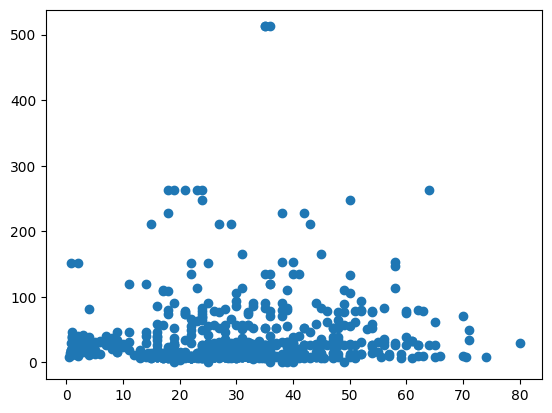

In [20]:
plt.scatter(x= df['Age'], y= df['Fare'])

 ## We can use seaborn to identify where we are missing data!!

In [26]:
# if we use the Pandas isnull function to identify empty dataset, 
#we can use below function which returns True if value not present, but the representation is not good
df.isnull()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

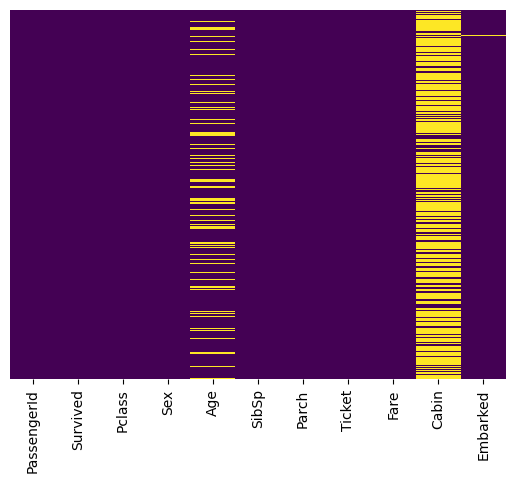

In [30]:
# thus we use seaborn for the same
# ytickerlabels and cbar remove left and right columns in graph (uselesss)
sns.heatmap(df.isnull(), yticklabels=False,cbar=False, cmap="viridis")

In [38]:
# next we also try to identify how many people survived, how many males among females died, and which class of people were most vulnerable

<Axes: xlabel='Survived', ylabel='count'>

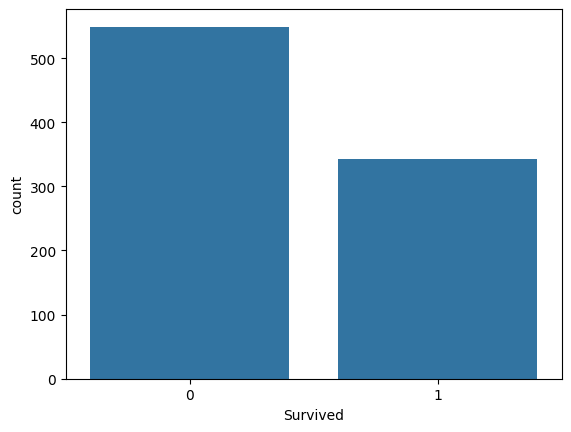

In [39]:
sns.countplot( x = "Survived", data=df)

<Axes: xlabel='Survived', ylabel='count'>

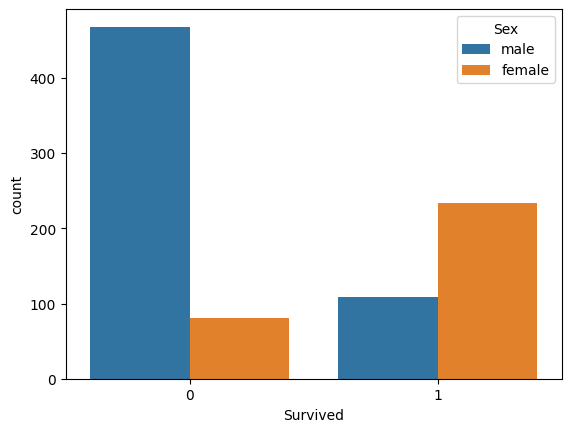

In [40]:
sns.countplot( x = "Survived", hue="Sex", data=df)

<Axes: xlabel='Survived', ylabel='count'>

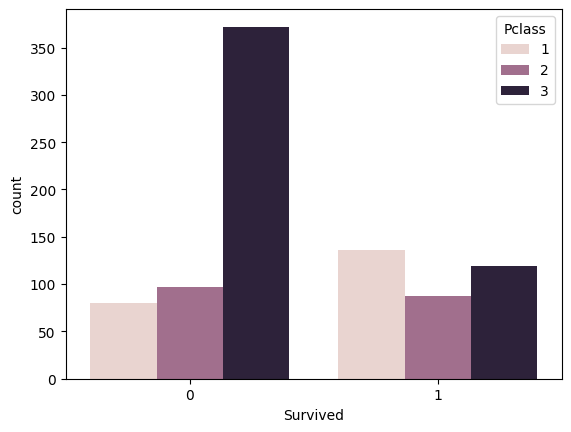

In [41]:
sns.countplot( x = "Survived", hue="Pclass", data=df)

In [42]:
# next we also check of what age most of the people were onboarded

<Axes: xlabel='Age', ylabel='Count'>

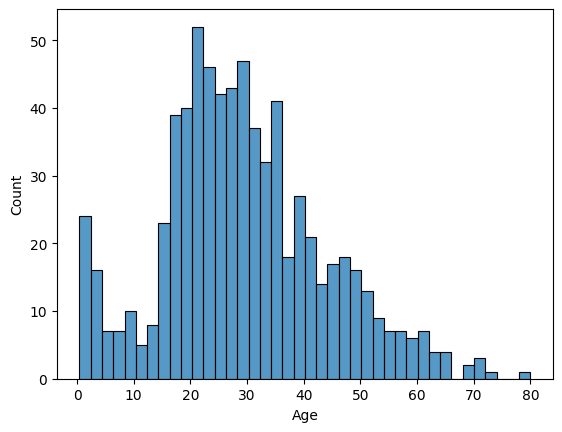

In [47]:
sns.histplot(bins=40,data=df['Age'].dropna(),kde=False)

<Axes: xlabel='SibSp', ylabel='count'>

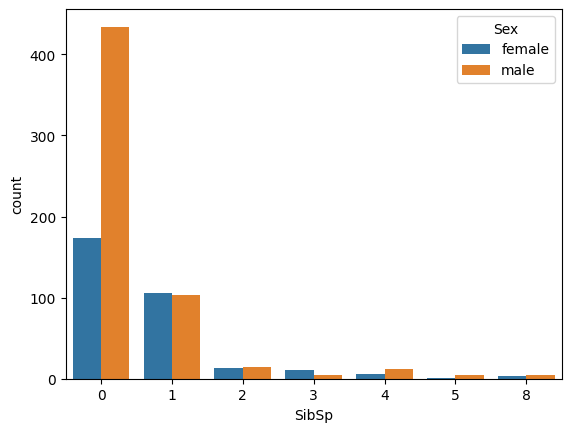

In [49]:
# next we try to check how many sibling or spouce most people had
sns.countplot(x='SibSp', hue='Sex', data=df)

<Axes: xlabel='Fare', ylabel='Count'>

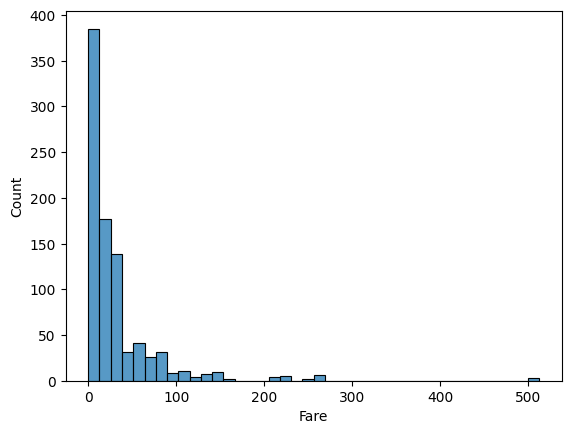

In [52]:
# next we try to find fare histogram also
sns.histplot(data=df, x=df['Fare'], bins=40)

### Data Cleaning

/tmp/ipykernel_1231/2553705890.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x=df['Pclass'],y=df['Age'],palette='winter')


<Axes: xlabel='Pclass', ylabel='Age'>

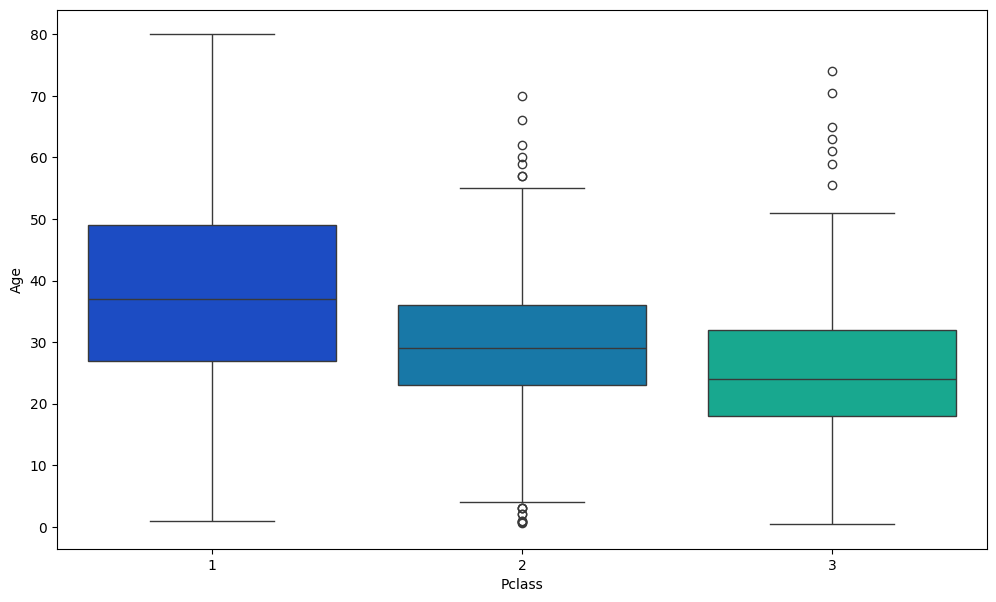

In [56]:
# before we begin updating the empty age value, we find a correlation between the age & the passenger class.
plt.figure(figsize=(12, 7))
sns.boxplot(data=df,x=df['Pclass'],y=df['Age'],palette='winter')

In [65]:
# now we will create afunction, that takes
def input_cols(data):
    Age = data[0]
    Pclass = data[1]

    if pd.isnull(Age):

        if Pclass==1:
           return 37
        elif Pclass==2:
           return 26
        else:
           return 23
    else:
        return Age

df['Age'] = df[['Age','Pclass']].apply(input_cols, axis=1)


/tmp/ipykernel_1231/2467998150.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = data[0]
/tmp/ipykernel_1231/2467998150.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = data[1]


<Axes: >

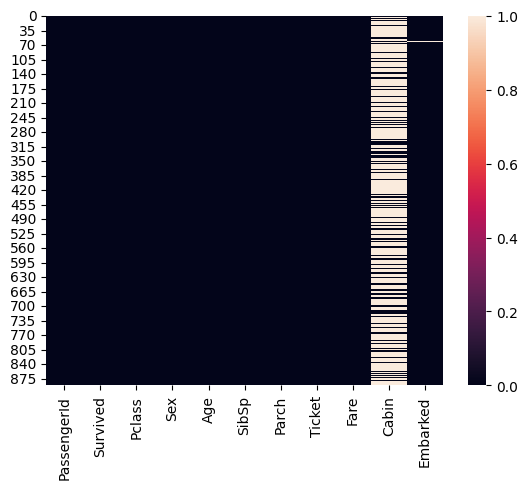

In [67]:
sns.heatmap(df.isnull())

In [79]:
if 'Cabin' in df.columns:
    df = df.drop('Cabin', axis =1) # remove column cabin across all rows --> for axis 1

In [81]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked'],
      dtype='object')


In [82]:
df.dropna(inplace=True)